# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version — Multi-Seed SAC + Ablation Study (Calmar vs CVaR Reward) + XAI Analysis

In [1]:
# ================================================================
# GLOBAL SETTINGS — THESIS-READY VERSION
# ================================================================
SEEDS         = [42, 123, 77]    # Multi-seed untuk reliabilitas statistik
TRAIN_STEPS   = 1000             # Sesuai gambar contoh
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95
STAT_ALPHA    = 0.05             # significance level untuk uji statistik

# Definisi eksperimen ablation
ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'extra_features': [], 'is_ensemble': True},
    
    # --- Baseline: Static Gamma ---
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

# Metrik utama yang dievaluasi dalam tesis
EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

In [2]:
# ================================================================
# IMPORTS
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import shap
from tqdm import tqdm
from scipy import stats
from scipy.optimize import minimize
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from networkx.algorithms import community

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Path output absolut — gambar tersimpan di folder yang sama dengan script ini
SCRIPT_DIR  = os.path.dirname(os.path.abspath(''))
OUTPUT_DIR  = os.path.join(os.getcwd(), 'ablation_results_thesis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Libraries loaded.')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')
print(f'SEEDS={SEEDS} | TRAIN_STEPS={TRAIN_STEPS} | CVaR level={CVAR_LEVEL*100:.0f}%')

Libraries loaded.
Ablation configs: ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg', 'Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2']
SEEDS=[42, 123, 77] | TRAIN_STEPS=1000 | CVaR level=95%


In [3]:
# ================================================================
# DATA LOADING
# ================================================================
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


In [4]:
# ================================================================
# SECTION 2A: Portfolio Optimization
# ================================================================

def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP. Fallback ke equal-weight jika infeasible."""
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0

def _build_mst_centrality(N, corr_f):
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec

def get_centrality_weights(returns_window, gamma=0.0):
    T, N = returns_window.shape
    mu     = returns_window.mean().values
    sigma  = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    _, cent_vec = _build_mst_centrality(N, corr_f)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)

def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))

def compute_classic_mv_weights(returns_window):
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun    = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    return res.x if res.success else w0

In [5]:
# ================================================================
# METRICS & HELPERS
# ================================================================

def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return dd, cumulative

def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    if total <= 0: return np.nan
    return total ** (periods_per_year / n) - 1

def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0

def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0: return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0

def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0

def calculate_cvar(ret_series, confidence=0.95):
    arr = np.array(ret_series)
    if len(arr) == 0: return 0.0
    var = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    return float(-np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0

def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0: return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd**2)))

def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Max Drawdown'    : max_dd,
        'Ulcer Index'     : calculate_ulcer_index(arr),
    }

In [6]:
# ================================================================
# VISUALIZATION HELPERS
# ================================================================

ABLATION_COLORS = {
    'E2_Sharpe'          : '#FF9800',
    'E2_Sortino'         : '#9C27B0',
    'E2_Calmar'          : '#2196F3',
    'E2_Ulcer'           : '#F44336',
    'E2_Ensemble_Avg'    : '#00BCD4',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
    'Classic-MV'         : '#3F51B5',
}

# Label tampilan yang lebih ringkas untuk plot
DISPLAY_NAMES = {
    'E2_Sharpe'          : 'E2-Sharpe',
    'E2_Sortino'         : 'E2-Sortino',
    'E2_Calmar'          : 'E2-Calmar',
    'E2_Ulcer'           : 'E2-Ulcer',
    'E2_Ensemble_Avg'    : 'E2-Ensemble',
    'Comp_Static_Gamma0' : 'γ=0 (Static)',
    'Comp_Static_Gamma1' : 'γ=1 (Static)',
    'Comp_Static_Gamma2' : 'γ=2 (Static)',
    'Classic-MV'         : 'Classic-MV',
}

def get_display_name(exp_id):
    """Mengembalikan nama tampilan yang lebih ringkas untuk digunakan di legenda plot."""
    return DISPLAY_NAMES.get(exp_id, exp_id)

# Mapping features for SHAP display
FEATURE_NAMES = [
    'MST.Dist x0.1', 'Spectral.Gap',
    'VolShort x100', 'VolLong x100', 'Vol.Ratio',
    'Mom5d x100', 'Mom20d x100', 'MomCross x100', 'Pct.Uptrend'
]

class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.current_episode_reward = 0
    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0
        return True

In [7]:
def plot_learning_curves(history_dict):
    plt.figure(figsize=(10, 4))
    for seed, rewards in history_dict.items():
        if len(rewards) == 0: continue
        smoothed = pd.Series(rewards).rolling(window=max(1, len(rewards)//10)).mean()
        plt.plot(smoothed, label=f'seed={seed}', alpha=0.8)
    plt.title(f'SAC Learning Curves — TRAIN_STEPS={TRAIN_STEPS} | SEEDS={SEEDS}\nKurva menghaluskan (rolling mean) reward per episode.', fontsize=12, fontweight='bold')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Reward')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(fontsize=8)
    
    # Add "(CHECK)" label like in the image
    plt.text(0.5, 1.05, 'E2_Sharpe\n(CHECK)', transform=plt.gca().transAxes, color='red', 
             fontweight='bold', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, 'learning_curves.png')
    plt.show()  # Tampilkan gambar
    plt.savefig(out_path, dpi=150, bbox_inches='tight') # Baru simpan
    plt.close()
    print(f'[SAVED] {out_path}')

In [8]:
def run_wilcoxon_tests(results_dict, baseline_id='Classic-MV'):
    stats_summary = []
    if baseline_id not in results_dict: return "Baseline not found"
    
    baseline_rets = results_dict[baseline_id].mean(axis=1) # Average across seeds
    
    for exp_id, rets_df in results_dict.items():
        if exp_id == baseline_id: continue
        exp_rets = rets_df.mean(axis=1)
        try:
            stat, p = stats.wilcoxon(exp_rets, baseline_rets)
            stats_summary.append(f"vs {exp_id}: p={p:.4f}")
        except:
            stats_summary.append(f"vs {exp_id}: error")
    return "\n ".join(stats_summary)

In [9]:
def generate_dashboard(results_dict, title_prefix, period_name, filename_base):
    # Calculate metrics for all experiments
    exp_ids = list(results_dict.keys())
    metrics_list = []
    
    for exp_id in exp_ids:
        rets_df = results_dict[exp_id]
        m_seeds = [calculate_all_metrics(rets_df[s], CVAR_LEVEL) for s in rets_df.columns]
        
        res = {'Experiment': exp_id, 'Features': 'Network(5) + Market(4)' if str(exp_id).startswith('E2') else 'Static/Baseline', 'Obs Dim': get_obs_dim(ABLATION_CONFIGS.get(exp_id, {})) if exp_id in ABLATION_CONFIGS else 0}
        
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in m_seeds]
            res[f'{m} Mean'] = np.mean(vals)
            res[f'{m} Std'] = np.std(vals)
        metrics_list.append(res)
    
    df_metrics = pd.DataFrame(metrics_list).sort_values(by='Sharpe Ratio Mean', ascending=False)
    
    # ------------------------------------------------------------------
    # DIAGRAM 1: Metrics Table & Bar Charts
    # ------------------------------------------------------------------
    fig1 = plt.figure(figsize=(16, 10), facecolor='white')
    gs1 = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1.0])
    fig1.suptitle(f'{title_prefix} — Metrics Comparison\nPeriod: {period_name.upper()} | Seeds: {SEEDS}', fontsize=14, fontweight='bold', y=0.98)

    # 1a. Table
    ax_table = fig1.add_subplot(gs1[0, :])
    ax_table.axis('off')
    table_data = []
    columns = ['Experiment', 'Features', 'Obs Dim', 'Sharpe (↑)', 'Sortino (↑)', 'Calmar (↑)', 'Ulcer (↓)', 'Rank']
    for i, (_, row) in enumerate(df_metrics.iterrows()):
        table_data.append([
            row['Experiment'], row['Features'], row['Obs Dim'],
            f"{row['Sharpe Ratio Mean']:.3f}±{row['Sharpe Ratio Std']:.3f}" if row['Sharpe Ratio Std']>1e-4 else f"{row['Sharpe Ratio Mean']:.3f}",
            f"{row['Sortino Ratio Mean']:.3f}±{row['Sortino Ratio Std']:.3f}" if row['Sortino Ratio Std']>1e-4 else f"{row['Sortino Ratio Mean']:.3f}",
            f"{row['Calmar Ratio Mean']:.3f}±{row['Calmar Ratio Std']:.3f}" if row['Calmar Ratio Std']>1e-4 else f"{row['Calmar Ratio Mean']:.3f}",
            f"{row['Ulcer Index Mean']:.4f}±{row['Ulcer Index Std']:.4f}" if row['Ulcer Index Std']>1e-4 else f"{row['Ulcer Index Mean']:.4f}",
            f"#{i+1}"
        ])
    table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 2)
    for (row_idx, col_idx), cell in table.get_celld().items():
        if row_idx == 0: cell.set_facecolor('#1976D2'); cell.set_text_props(color='white', fontweight='bold')
        elif row_idx % 2 == 0: cell.set_facecolor('#F0F7FF')
    ax_table.set_title('Rangkuman Metrik Performa (Mean ± Std)', fontsize=11, fontweight='bold', pad=15)

    # 1b. Bar Charts
    for i, m in enumerate(EVAL_METRICS):
        ax = fig1.add_subplot(gs1[1, i])
        means = [row[f'{m} Mean'] for _, row in df_metrics.iterrows()]
        stds = [row[f'{m} Std'] for _, row in df_metrics.iterrows()]
        exps = [row['Experiment'] for _, row in df_metrics.iterrows()]
        colors = [ABLATION_COLORS.get(e, '#777777') for e in exps]
        bars = ax.bar(exps, means, yerr=stds, color=colors, capsize=3, alpha=0.8)
        label = "(↓ lebih kecil baik)" if "Ulcer" in m else "(↑ lebih besar baik)"
        ax.set_title(f'{m}\n{label}', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7); ax.axhline(0, color='black', lw=0.5)
        ax.set_xticklabels([get_display_name(e) for e in exps], rotation=45, ha='right')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    path1 = os.path.join(OUTPUT_DIR, f"1_metrics_{filename_base}")
    plt.show(); plt.savefig(path1, dpi=200, bbox_inches='tight'); plt.close()

    # ------------------------------------------------------------------
    # DIAGRAM 2: Cumulative Returns
    # ------------------------------------------------------------------
    fig2 = plt.figure(figsize=(16, 7), facecolor='white')
    ax_cum = fig2.add_subplot(111)
    for exp_id in exp_ids:
        avg_rets = results_dict[exp_id].mean(axis=1)
        cum_rets = (1 + avg_rets).cumprod()
        ax_cum.plot(cum_rets, label=get_display_name(exp_id), color=ABLATION_COLORS.get(exp_id, '#777777'), lw=2.5 if str(exp_id).startswith('E2') else 1.2)
    ax_cum.axhline(1.0, color='grey', ls='--', lw=0.8)
    ax_cum.set_title(f'Cumulative Returns (Mean across {len(SEEDS)} seeds) — {period_name.capitalize()} Period', fontsize=14, fontweight='bold')
    ax_cum.set_ylabel('Growth of 1.0 Unit', fontsize=12); ax_cum.legend(fontsize=9, ncol=4, loc='upper left')
    ax_cum.grid(True, alpha=0.3)
    
    plt.tight_layout()
    path2 = os.path.join(OUTPUT_DIR, f"2_returns_{filename_base}")
    plt.show(); plt.savefig(path2, dpi=200, bbox_inches='tight'); plt.close()

    # ------------------------------------------------------------------
    # DIAGRAM 3: Stats & Interpretation
    # ------------------------------------------------------------------
    fig3 = plt.figure(figsize=(16, 6), facecolor='white')
    gs3 = gridspec.GridSpec(1, 2)
    fig3.suptitle(f'{title_prefix} — Statistical Summary & Interpretation', fontsize=14, fontweight='bold', y=0.98)

    ax_stat = fig3.add_subplot(gs3[0, 0]); ax_stat.axis('off')
    stat_text = run_wilcoxon_tests(results_dict, 'Classic-MV')
    ax_stat.text(0, 1, f"UJI STATISTIK: E2 Models vs Baseline\n(α=0.05, Wilcoxon Signed-Rank)\n\n {stat_text}", 
                 fontsize=10, family='monospace', bbox=dict(facecolor='#F1F8E9', alpha=0.8, boxstyle='round,pad=1'), va='top')

    ax_interp = fig3.add_subplot(gs3[0, 1]); ax_interp.axis('off')
    best_sharpe = df_metrics.iloc[0]['Experiment']
    interp_text = f"INTERPRETASI OTOMATIS:\n\n"
    interp_text += f"Top Sharpe Model    : {best_sharpe} ({df_metrics.iloc[0]['Sharpe Ratio Mean']:.4f})\n"
    interp_text += f"Top Sortino Model   : {df_metrics.sort_values('Sortino Ratio Mean', ascending=False).iloc[0]['Experiment']}\n"
    interp_text += f"Top Risk-Adjusted   : {df_metrics.sort_values('Ulcer Index Mean', ascending=True).iloc[0]['Experiment']} (Best Ulcer)\n\n"
    
    base_s = df_metrics[df_metrics['Experiment']=='Classic-MV']['Sharpe Ratio Mean'].values[0]
    e2_s = df_metrics[df_metrics['Experiment']=='E2_Sharpe']['Sharpe Ratio Mean'].values[0] if 'E2_Sharpe' in df_metrics['Experiment'].values else 0
    interp_text += f"IMPROVEMENT vs BASELINE (Sharpe):\nΔ: {e2_s - base_s:+.4f}"
    
    ax_interp.text(0, 1, interp_text, fontsize=10, family='monospace', bbox=dict(facecolor='#E8EAF6', alpha=0.8, boxstyle='round,pad=1'), va='top')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    path3 = os.path.join(OUTPUT_DIR, f"3_interpretation_{filename_base}")
    plt.show(); plt.savefig(path3, dpi=200, bbox_inches='tight'); plt.close()
    
    print(f'[SAVED] 3 Dashboard images saved in {OUTPUT_DIR}')

In [10]:
def plot_shap_analysis(model_paths, env, config, exp_id):
    """
    Generates SHAP analysis for a single model or an ensemble of models.
    model_paths: can be a single path string or a list of paths for ensemble.
    """
    print(f"Generating SHAP analysis for {exp_id}...")
    
    import torch
    models = []
    if isinstance(model_paths, list):
        for p in model_paths: models.append(SAC.load(p))
    else:
        models.append(SAC.load(model_paths))
    
    # Sample background and test data
    obs_list = []
    for _ in range(100):
        obs, _ = env.reset()
        done = False
        while not done and len(obs_list) < 400:
            obs_list.append(obs)
            # Use first model for sampling trajectory
            action, _ = models[0].predict(obs, deterministic=True)
            obs, rew, done, _, _ = env.step(action)
    
    X = np.array(obs_list)
    df_X = pd.DataFrame(X, columns=FEATURE_NAMES[:X.shape[1]])
    
    def predict_action(x):
        # x can be a numpy array or a DataFrame, convert to numpy for torch
        x_torch = torch.tensor(np.array(x), dtype=torch.float32)
        with torch.no_grad():
            all_actions = []
            for m in models:
                all_actions.append(m.policy.actor(x_torch).numpy())
            # Average actions across models
            avg_actions = np.mean(all_actions, axis=0)
        return avg_actions

    explainer = shap.Explainer(predict_action, df_X[:100])
    shap_values = explainer(df_X[100:300])
    
    # Summary Plot (Beeswarm)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, df_X[100:300], show=False)
    plt.title(f'SHAP Feature Importance — {exp_id}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_summary = os.path.join(OUTPUT_DIR, f'shap_summary_{exp_id}.png')
    plt.show()
    plt.savefig(out_summary, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'[SAVED] {out_summary}')
    
    # Bar Plot
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, show=False)
    plt.title(f'SHAP Mean |Value| — {exp_id}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_bar = os.path.join(OUTPUT_DIR, f'shap_bar_{exp_id}.png')
    plt.show()
    plt.savefig(out_bar, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'[SAVED] {out_bar}')

In [11]:
# ================================================================
# FEATURE ENGINEERING & CACHE
# ================================================================

def compute_network_features(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec

def compute_market_features(returns_window, port_val=0.0):
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5, v20 = arr[-win5:].std(axis=0).mean(), arr[-win20:].std(axis=0).mean()
    m5, m20 = arr[-win5:].mean(axis=0).mean(), arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([v5*100, v20*100, v5/(v20+1e-8), m5*100, m20*100, (m5-m20)*100, pct_up], dtype=np.float32)

GLOBAL_CACHE = {}
print('Precomputing cache...')
for i in tqdm(range(SET_WINDOW, len(ret_train))):
    win = ret_train.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}

for i in tqdm(range(SET_WINDOW, len(ret_test))):
    win = ret_test.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[len(ret_train)+i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}

FEAT_MEAN = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).mean(axis=0)
FEAT_STD  = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).std(axis=0) + 1e-8

def build_observation(win, config, nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None: nw_feat_raw, corr_f, _ = compute_network_features(win)
    obs = []
    if config['use_network']: obs.append((nw_feat_raw - FEAT_MEAN)/FEAT_STD)
    if config['use_market']:  obs.append(compute_market_features(win))
    return np.nan_to_num(np.concatenate(obs)), corr_f

def get_obs_dim(config):
    d = 0
    if config['use_network']: d += 2
    if config['use_market']:  d += 7
    return max(d, 1)

Precomputing cache...


100%|██████████| 199/199 [00:13<00:00, 15.21it/s]


In [12]:
# ================================================================
# RL ENVIRONMENT WITH CVAR REWARD OPTION
# ================================================================

class AblationPortfolioEnv(gym.Env):
    def __init__(self, data, config, data_start_offset=0):
        super().__init__()
        self.data = data
        self.config = config
        self.offset = data_start_offset
        self.current_step = SET_WINDOW
        self._returns_buffer = []
        self._rew_stats = {'mean': 0, 'M2': 0, 'count': 0}
        
        dim = get_obs_dim(config)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _get_obs(self):
        idx = self.offset + self.current_step
        c = GLOBAL_CACHE[idx]
        obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f'])
        return obs

    def reset(self, seed=None, options=None):
        self.current_step = SET_WINDOW
        self._returns_buffer = []
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        idx = self.offset + self.current_step
        c = GLOBAL_CACHE[idx]
        w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW: self._returns_buffer.pop(0)
        
        arr = np.array(self._returns_buffer)
        reward_type = self.config.get('reward_type', 'calmar')
        
        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe':
                raw_reward = float(np.clip(calculate_sharpe_ratio(arr), -10.0, 10.0))
            elif reward_type == 'sortino':
                raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar':
                raw_reward = float(np.clip(calculate_calmar_ratio(arr), -10.0, 10.0))
            elif reward_type == 'ulcer':
                ann_ret = calculate_annualized_return(arr)
                ulcer = calculate_ulcer_index(arr)
                raw_reward = float(np.clip(ann_ret / ulcer if ulcer > 1e-8 else ann_ret / 1e-8, -10.0, 10.0))
            else:
                raw_reward = 0.0

        # Reward Normalization
        s = self._rew_stats
        s['count'] += 1
        d = raw_reward - s['mean']
        s['mean'] += d / s['count']
        s['M2'] += d * (raw_reward - s['mean'])
        std = np.sqrt(s['M2']/s['count']) if s['count'] > 1 else 1.0
        reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))
        
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs() if not done else np.zeros(self.observation_space.shape), reward, done, False, {}


Training E2_Sharpe...
   [SKIP] Model model_E2_Sharpe_s42 sudah ada.
   [SKIP] Model model_E2_Sharpe_s123 sudah ada.
   [SKIP] Model model_E2_Sharpe_s77 sudah ada.

Training E2_Sortino...
   [SKIP] Model model_E2_Sortino_s42 sudah ada.
   [SKIP] Model model_E2_Sortino_s123 sudah ada.
   [SKIP] Model model_E2_Sortino_s77 sudah ada.

Training E2_Calmar...
   [SKIP] Model model_E2_Calmar_s42 sudah ada.
   [SKIP] Model model_E2_Calmar_s123 sudah ada.
   [SKIP] Model model_E2_Calmar_s77 sudah ada.

Training E2_Ulcer...
   [SKIP] Model model_E2_Ulcer_s42 sudah ada.
   [SKIP] Model model_E2_Ulcer_s123 sudah ada.
   [SKIP] Model model_E2_Ulcer_s77 sudah ada.


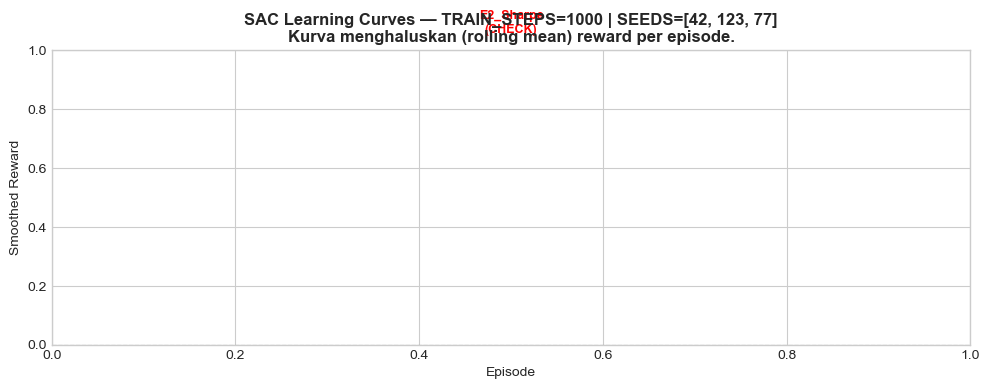

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\learning_curves.png


In [13]:
# ================================================================
# TRAINING & EVALUATION
# ================================================================

trained_models = {}
train_histories = {}

# 1. RL Training
for exp_id, config in ABLATION_CONFIGS.items():
    if config.get('static_gamma') is not None or config.get('is_ensemble'): continue
    print(f'\nTraining {exp_id}...')
    train_histories[exp_id] = {}
    for seed in SEEDS:
        name = f'model_{exp_id}_s{seed}'
        # Bypass training if model already exists
        if os.path.exists(name + ".zip"):
            print(f'   [SKIP] Model {name} sudah ada.')
            trained_models[(exp_id, seed)] = name
            continue
            
        env = AblationPortfolioEnv(ret_train, config, 0)
        callback = RewardLoggerCallback()
        model = SAC('MlpPolicy', env, seed=seed, verbose=0, learning_rate=3e-4)
        model.learn(total_timesteps=TRAIN_STEPS, callback=callback, progress_bar=True)
        
        model.save(name)
        trained_models[(exp_id, seed)] = name
        train_histories[exp_id][seed] = callback.episode_rewards

# Plot Learning Curves for E2
if 'E2_Sharpe' in train_histories:
    plot_learning_curves(train_histories['E2_Sharpe'])

In [14]:
# 2. Backtest (Train & Test)
results_test = {}
results_train = {}

# Include Classic-MV baseline
for exp_id in tqdm(list(ABLATION_CONFIGS.keys()) + ['Classic-MV'], desc='Backtesting'):
    results_test[exp_id] = pd.DataFrame()
    results_train[exp_id] = pd.DataFrame()
    
    config = ABLATION_CONFIGS.get(exp_id, {})
    
    for seed in SEEDS:
        # Load model once per seed if needed
        model = None
        ensemble_models = []
        if exp_id not in ['Classic-MV'] and config.get('static_gamma') is None:
            if config.get('is_ensemble'):
                ensemble_models.append(SAC.load(trained_models[('E2_Sharpe', seed)]))
                ensemble_models.append(SAC.load(trained_models[('E2_Sortino', seed)]))
                ensemble_models.append(SAC.load(trained_models[('E2_Calmar', seed)]))
                ensemble_models.append(SAC.load(trained_models[('E2_Ulcer', seed)]))
            else:
                model = SAC.load(trained_models[(exp_id, seed)])
            
        # Testing Re-run
        rets_test = []
        for i in range(SET_WINDOW, len(ret_test)):
            idx = len(ret_train) + i
            c = GLOBAL_CACHE[idx]
            
            if exp_id == 'Classic-MV':
                w = compute_classic_mv_weights(c['win'])
            elif config.get('static_gamma') is not None:
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
            elif config.get('is_ensemble'):
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                gammas = [float(em.predict(obs, deterministic=True)[0][0]) for em in ensemble_models]
                gamma_final = sum(gammas) / len(gammas)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma_final)
            else:
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                action, _ = model.predict(obs, deterministic=True)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
            
            rets_test.append(np.dot(w, ret_test.iloc[i].values))
        
        results_test[exp_id][seed] = pd.Series(rets_test, index=ret_test.index[SET_WINDOW:])
        
        # Training Re-run (for Train Dashboard)
        rets_train_eval = []
        for i in range(SET_WINDOW, len(ret_train)):
            c = GLOBAL_CACHE[i]
            
            if exp_id == 'Classic-MV':
                w = compute_classic_mv_weights(c['win'])
            elif config.get('static_gamma') is not None:
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
            elif config.get('is_ensemble'):
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                gammas = [float(em.predict(obs, deterministic=True)[0][0]) for em in ensemble_models]
                gamma_final = sum(gammas) / len(gammas)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma_final)
            else:
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                action, _ = model.predict(obs, deterministic=True)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
            
            rets_train_eval.append(np.dot(w, ret_train.iloc[i].values))
        
        results_train[exp_id][seed] = pd.Series(rets_train_eval, index=ret_train.index[SET_WINDOW:])

Backtesting: 100%|██████████| 9/9 [03:03<00:00, 20.43s/it]



Generating Final Dashboards...


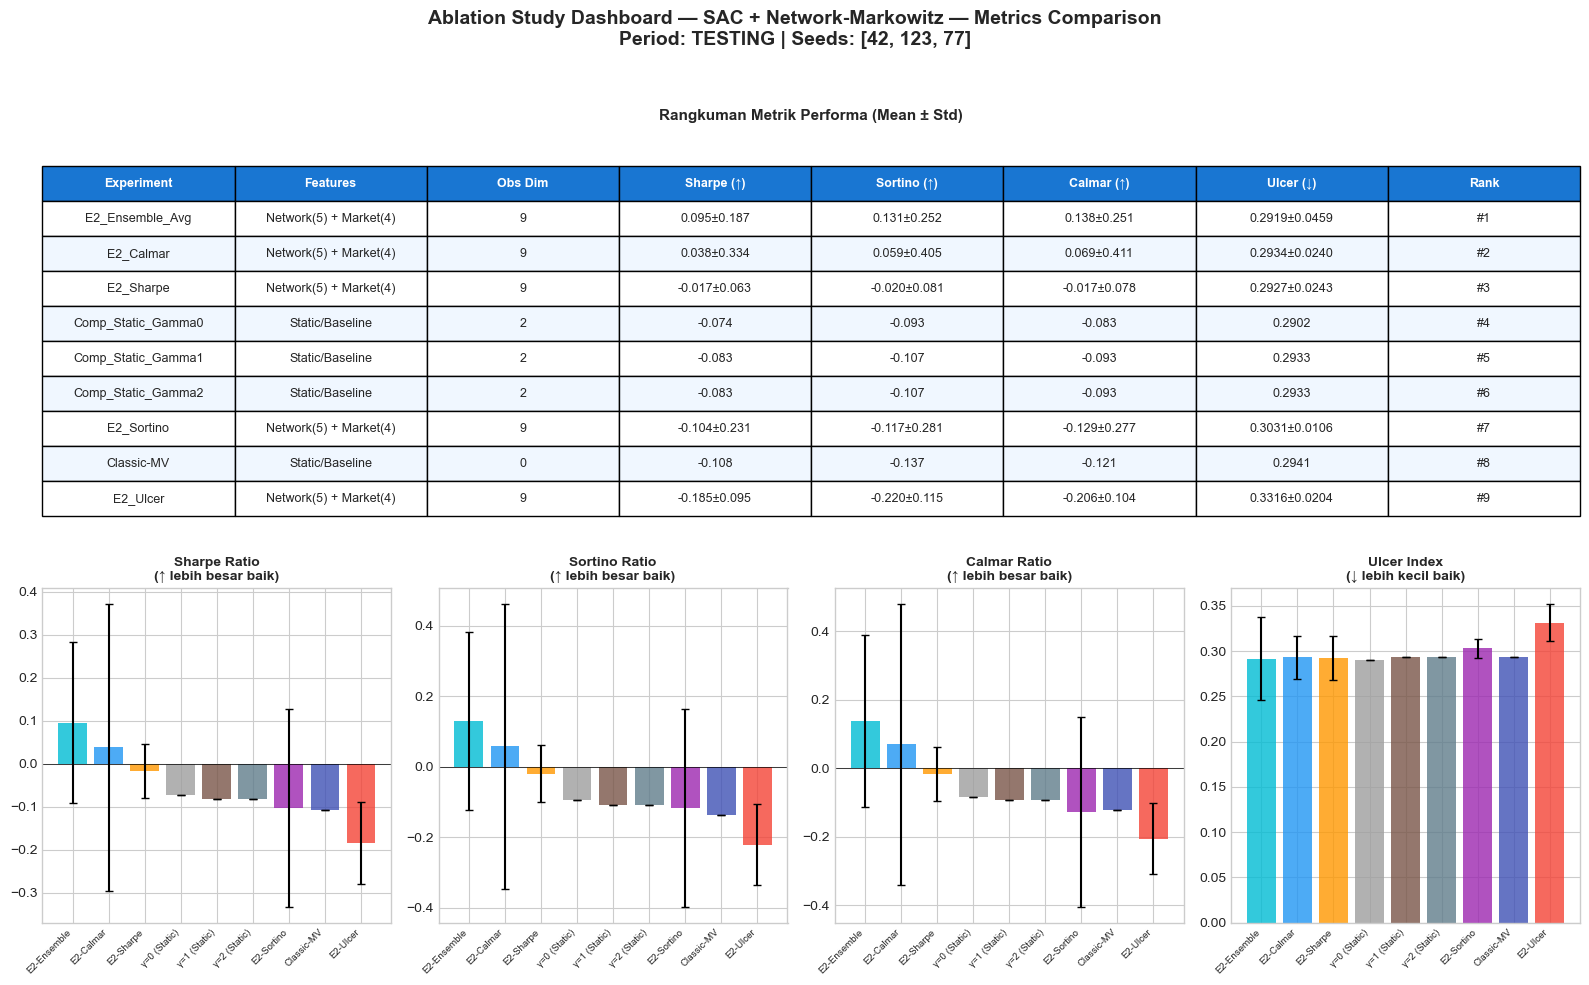

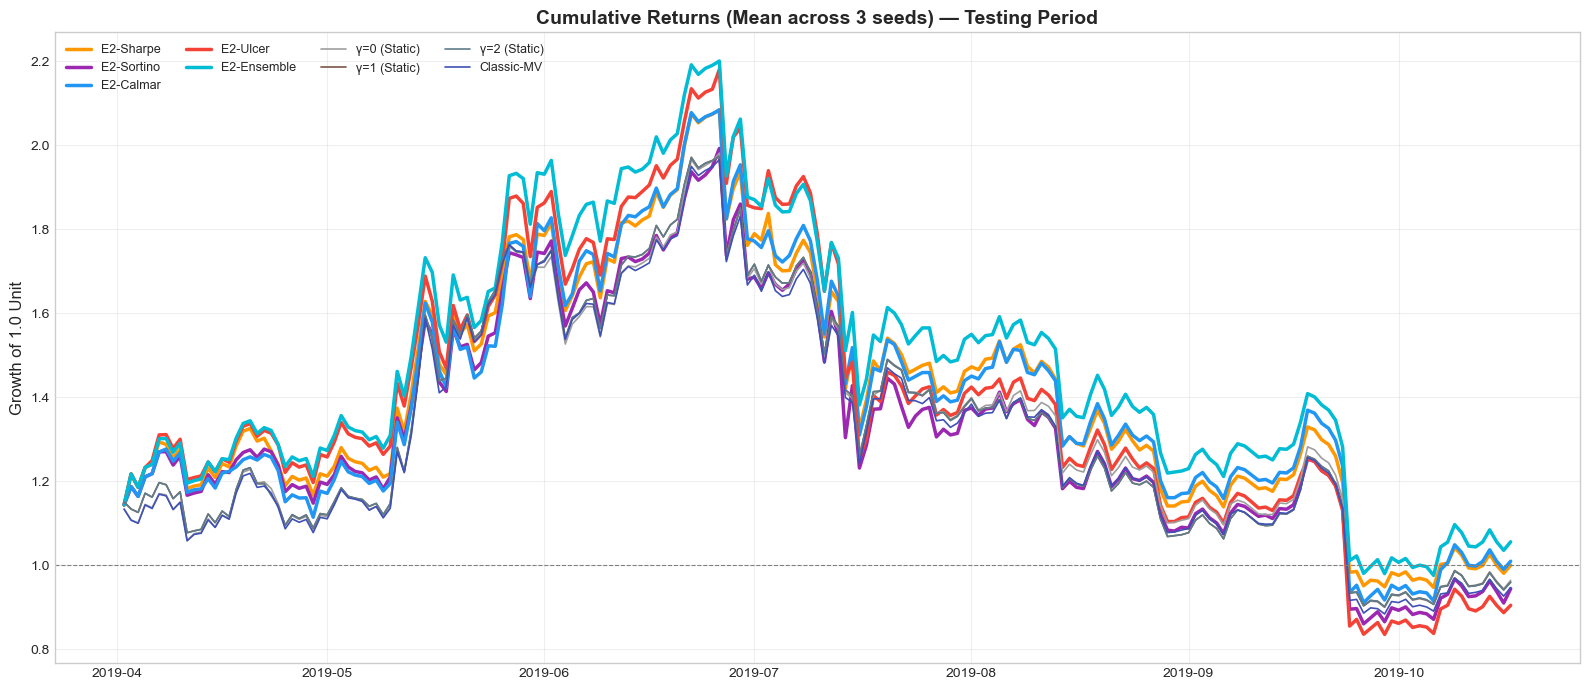

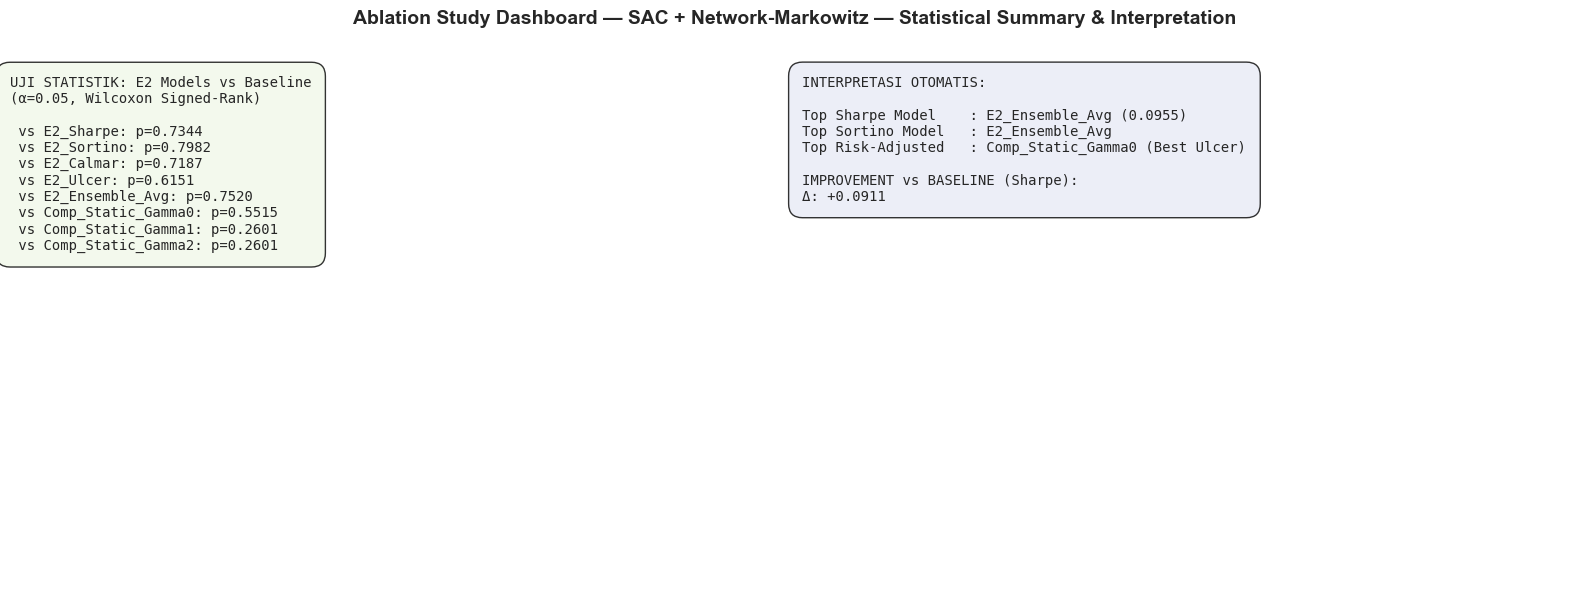

[SAVED] 3 Dashboard images saved in g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis


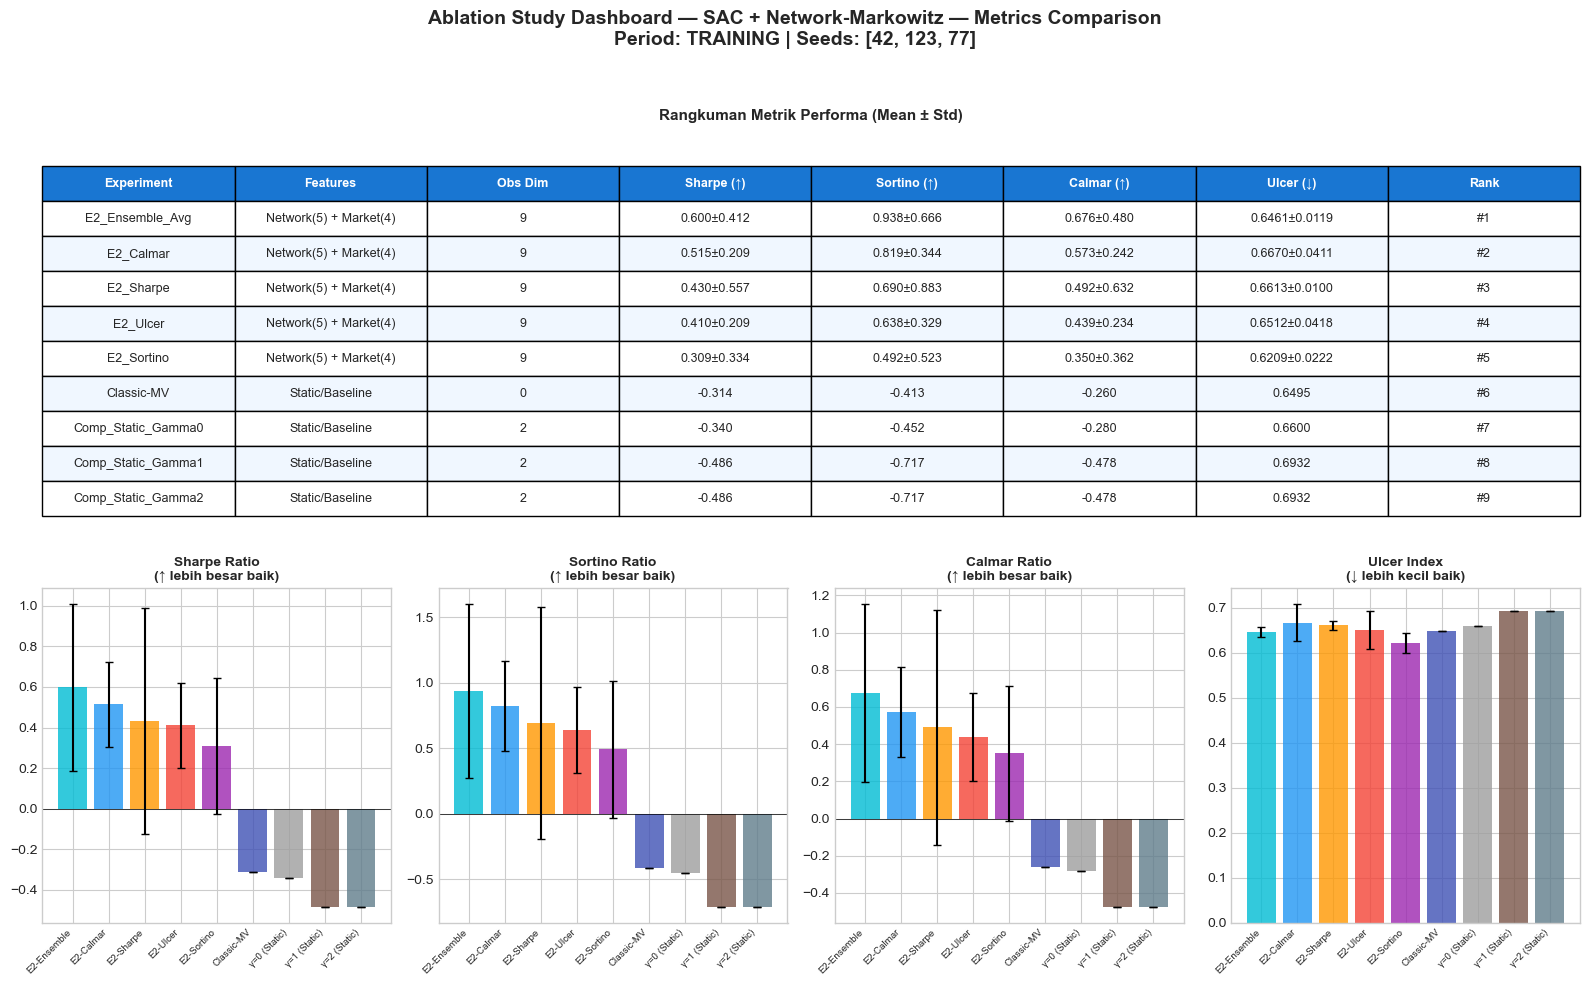

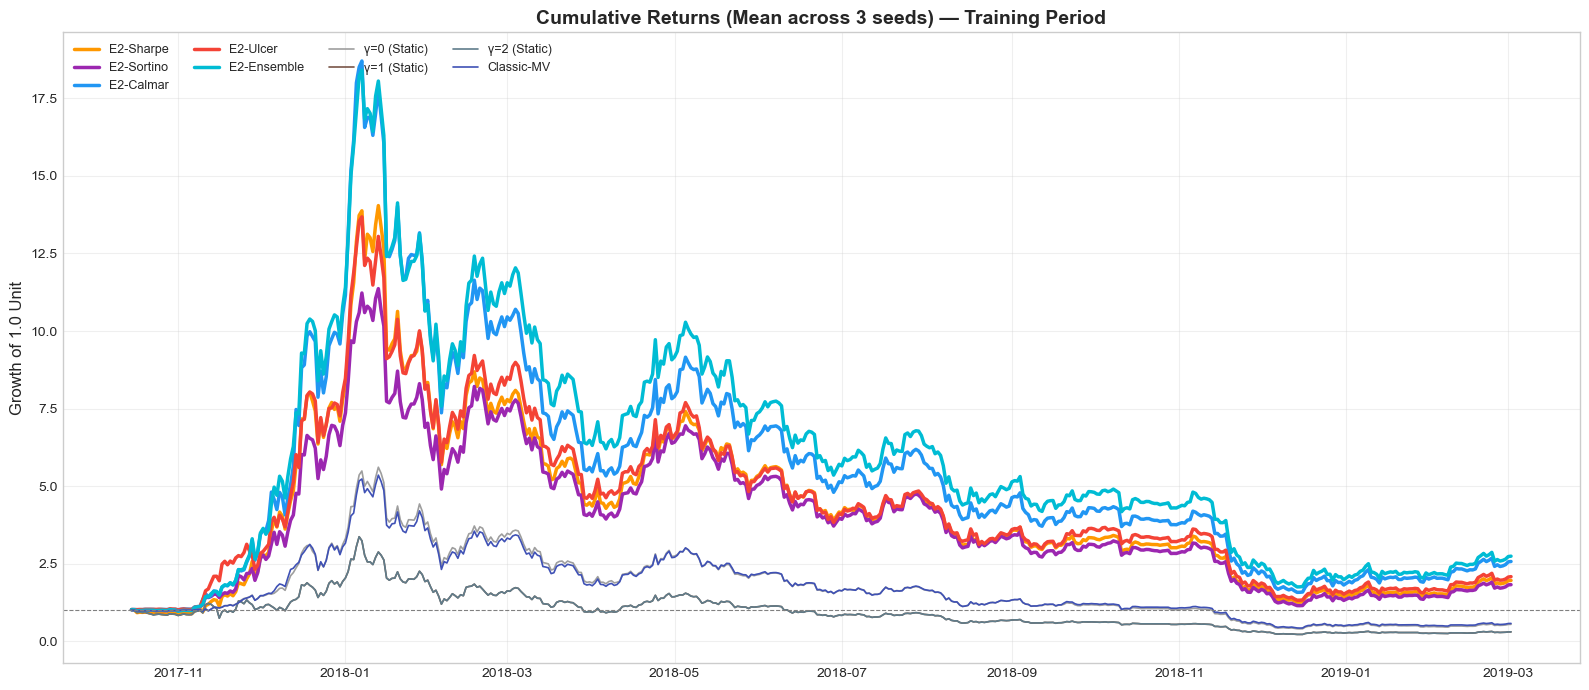

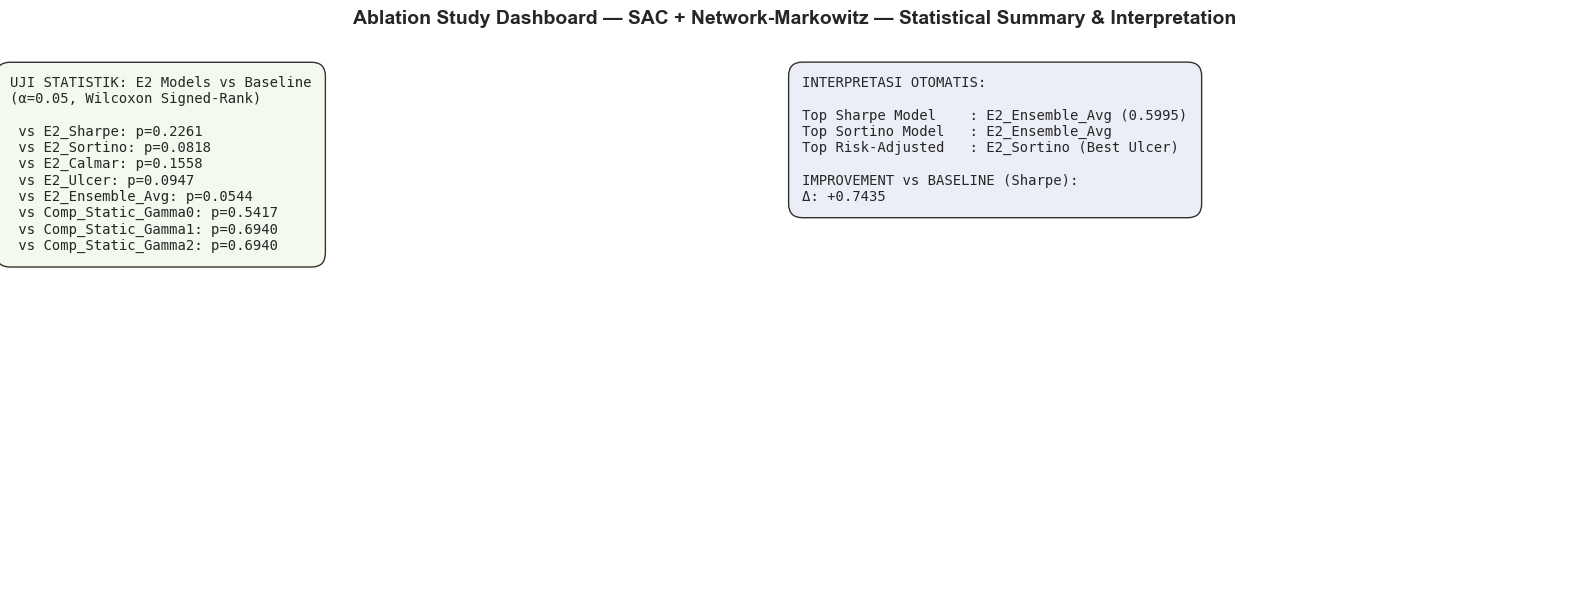

[SAVED] 3 Dashboard images saved in g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis

Generating SHAP analysis for all E2 models...
Generating SHAP analysis for E2_Sharpe...


ExactExplainer explainer: 201it [00:20,  7.93it/s]                         


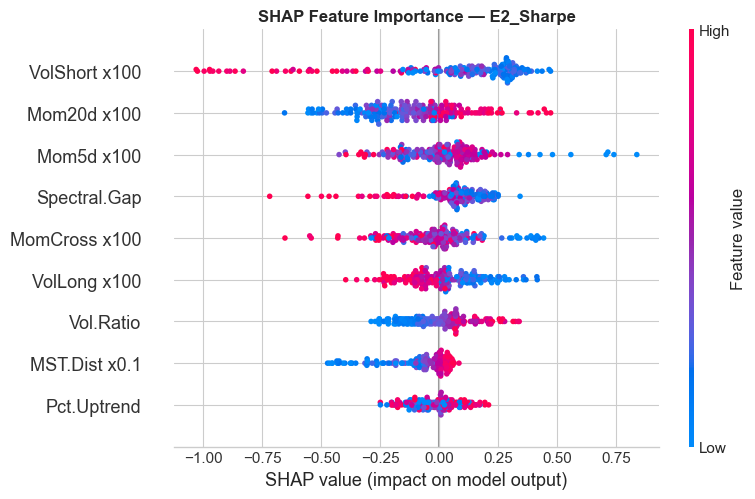

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_summary_E2_Sharpe.png


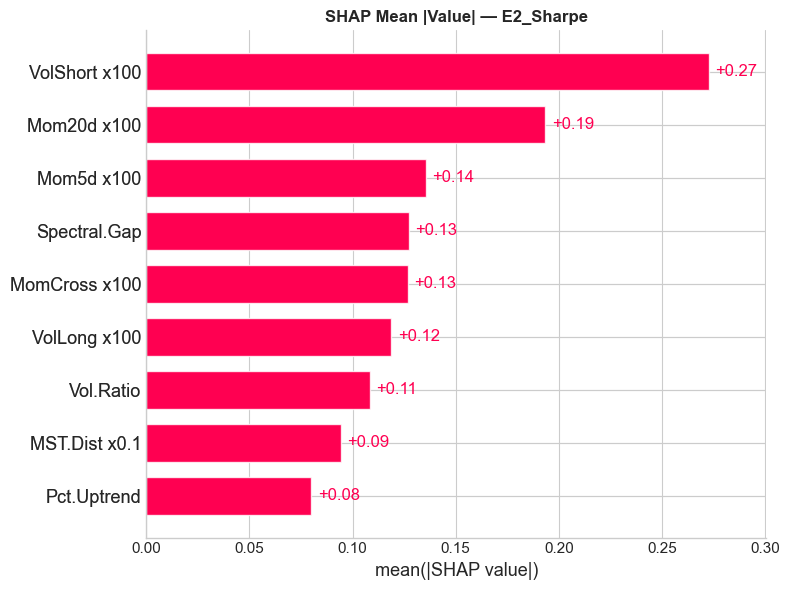

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_bar_E2_Sharpe.png
Generating SHAP analysis for E2_Sortino...


ExactExplainer explainer: 201it [00:13,  3.79it/s]                         


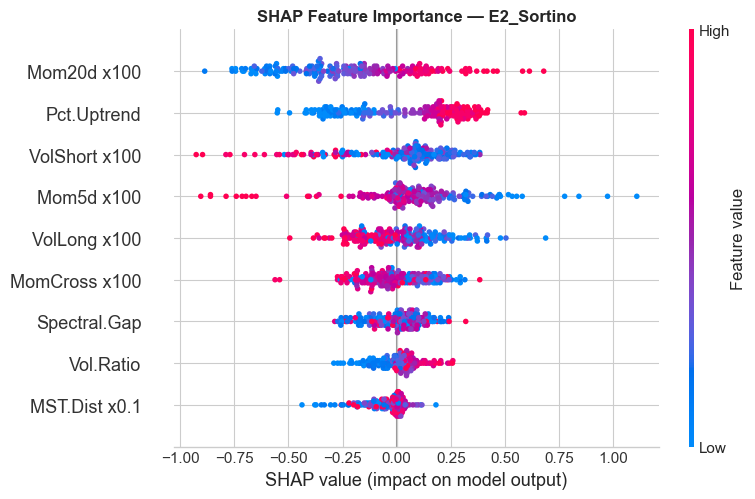

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_summary_E2_Sortino.png


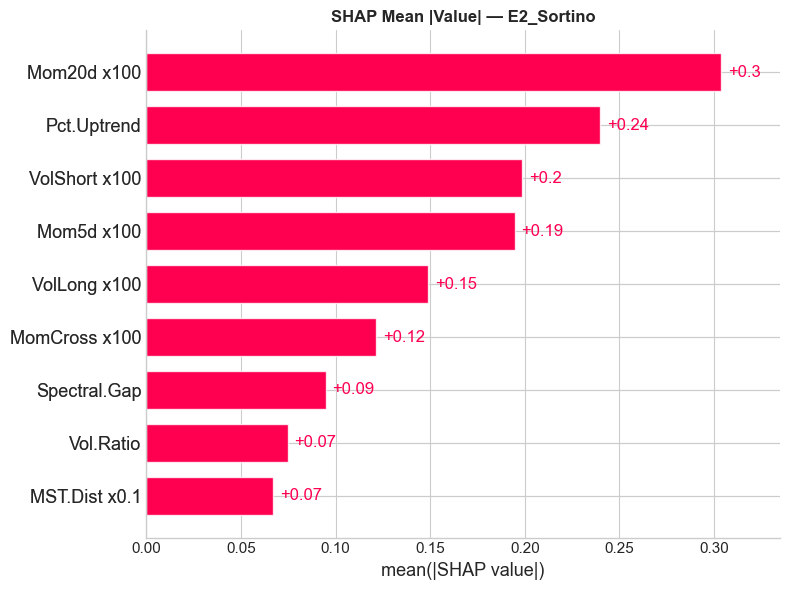

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_bar_E2_Sortino.png
Generating SHAP analysis for E2_Calmar...


ExactExplainer explainer: 201it [00:12,  2.99it/s]                         


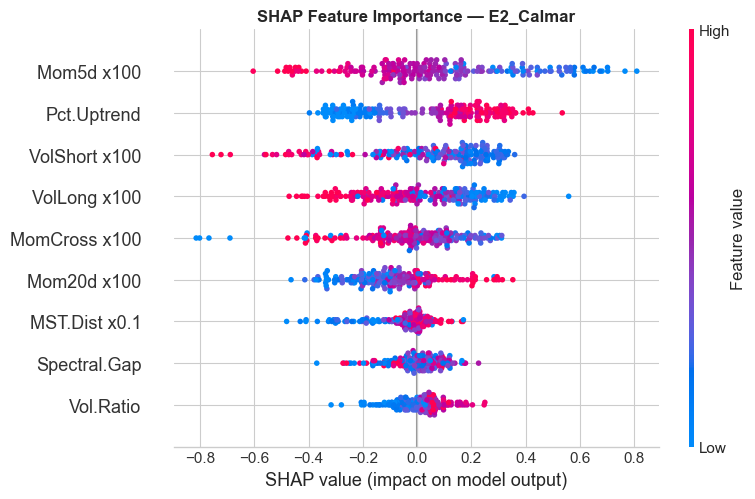

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_summary_E2_Calmar.png


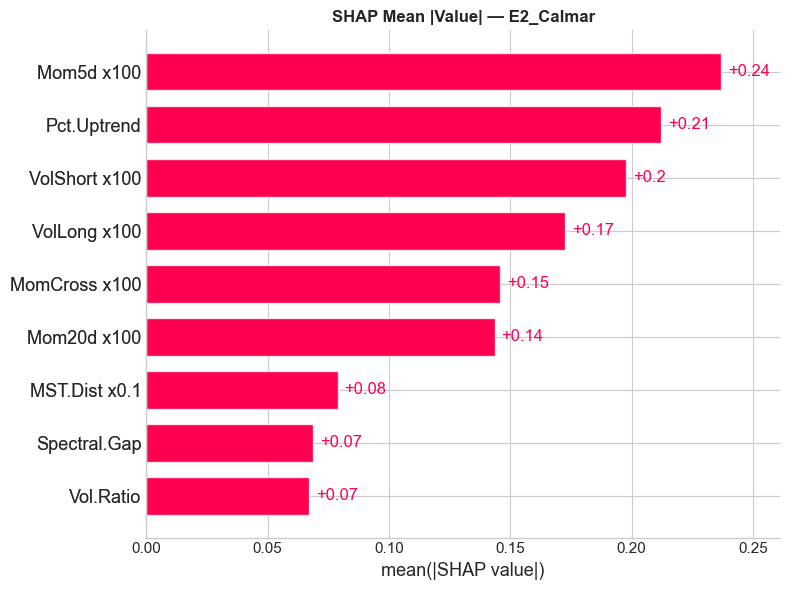

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_bar_E2_Calmar.png
Generating SHAP analysis for E2_Ulcer...


ExactExplainer explainer: 201it [00:12,  3.16it/s]                         


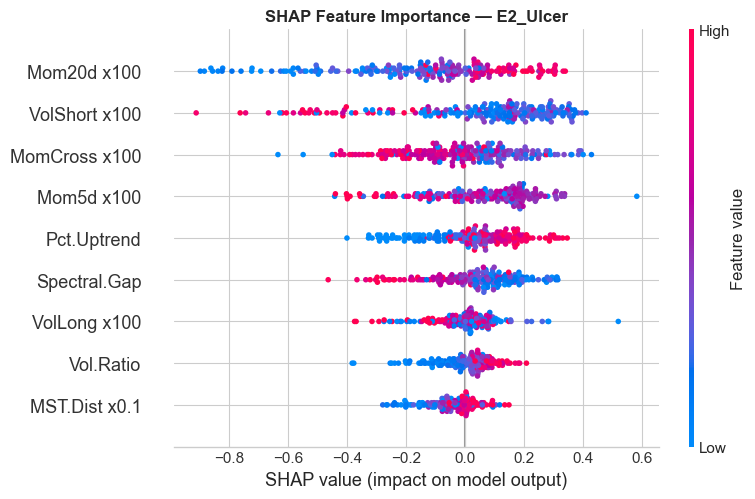

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_summary_E2_Ulcer.png


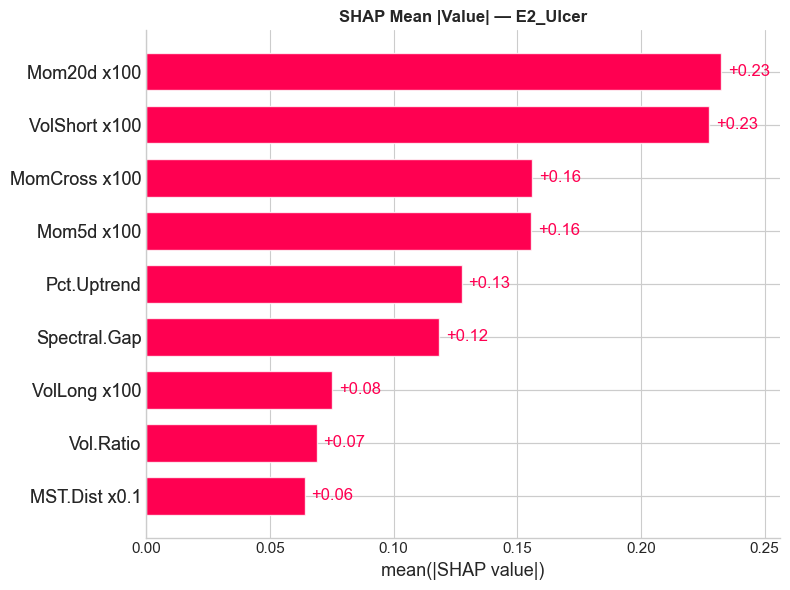

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_bar_E2_Ulcer.png
Generating SHAP analysis for E2_Ensemble_Avg...


ExactExplainer explainer: 201it [00:44,  3.50it/s]                         


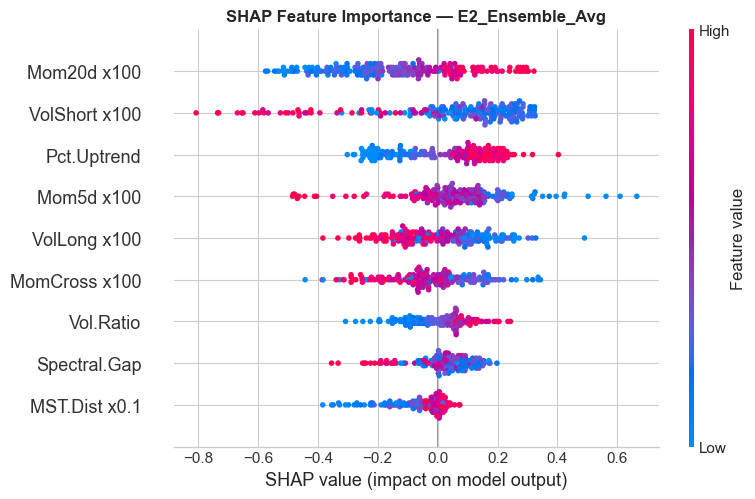

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_summary_E2_Ensemble_Avg.png


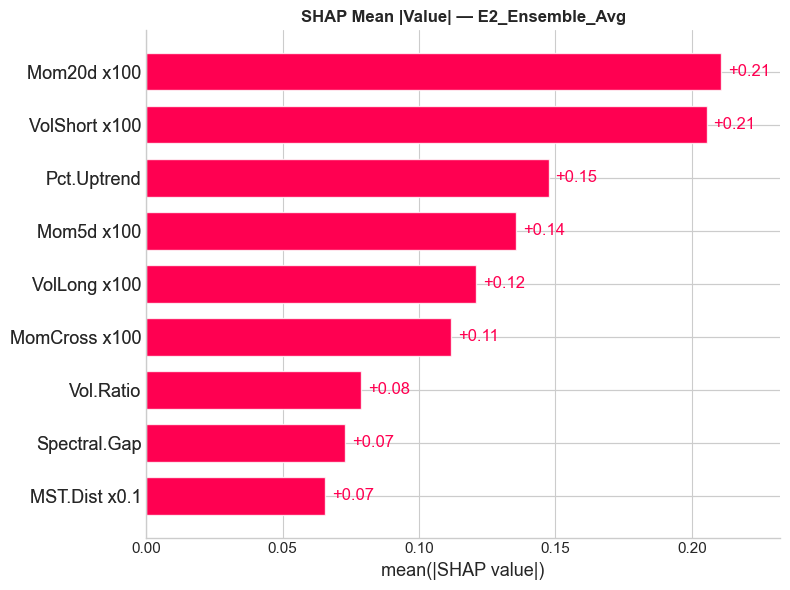

[SAVED] g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis\shap_bar_E2_Ensemble_Avg.png

Processing complete. Files saved in 'ablation_results_thesis/'.


In [15]:
# 3. Generate Dashboards
print("\nGenerating Final Dashboards...")
generate_dashboard(results_test, "Ablation Study Dashboard — SAC + Network-Markowitz", "Testing", "testing.png")
generate_dashboard(results_train, "Ablation Study Dashboard — SAC + Network-Markowitz", "Training", "training.png")

# 4. SHAP Analysis for All E2 Models
print("\nGenerating SHAP analysis for all E2 models...")
seed0 = SEEDS[0]
for exp_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg']:
    config = ABLATION_CONFIGS.get(exp_id, {})
    
    # Load model path(s)
    if exp_id == 'E2_Ensemble_Avg':
        # Ensemble loads all 4 base models
        m_paths = [
            trained_models.get(('E2_Sharpe', seed0)),
            trained_models.get(('E2_Sortino', seed0)),
            trained_models.get(('E2_Calmar', seed0)),
            trained_models.get(('E2_Ulcer', seed0))
        ]
        # Filter out None if some models failed to train
        m_paths = [p for p in m_paths if p is not None and os.path.exists(p + ".zip")]
        if len(m_paths) == 0: continue
    else:
        m_paths = trained_models.get((exp_id, seed0))
        if m_paths is None or not os.path.exists(m_paths + ".zip"): continue

    env_eval = AblationPortfolioEnv(ret_test, config, len(ret_train))
    plot_shap_analysis(m_paths, env_eval, config, exp_id)

print("\nProcessing complete. Files saved in 'ablation_results_thesis/'.")


--- RESULTS PREVIEW ---

Displaying 1_metrics_testing.png:


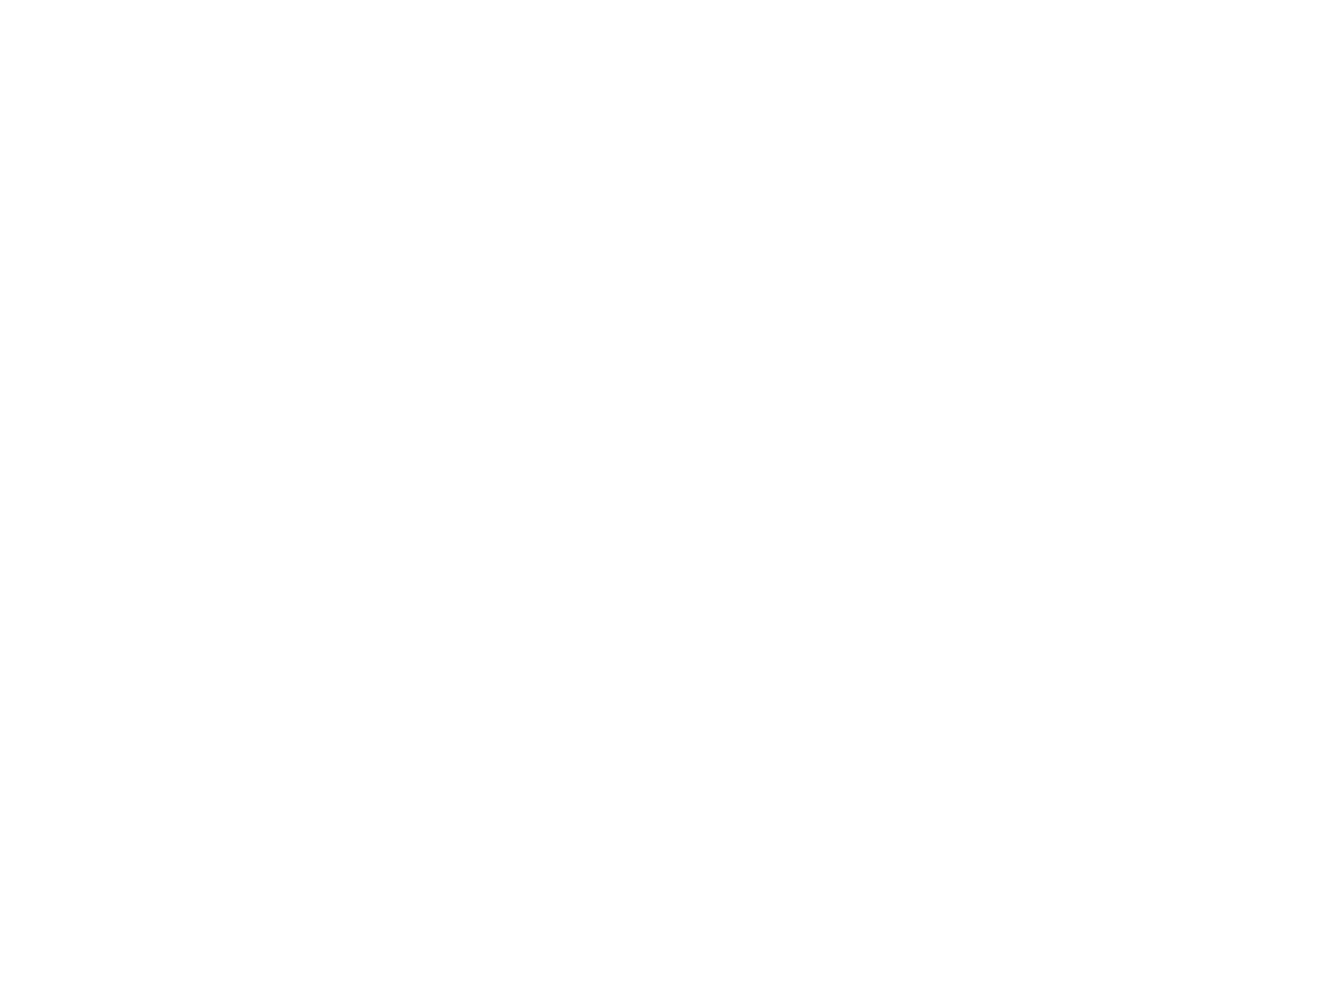


Displaying 2_returns_testing.png:


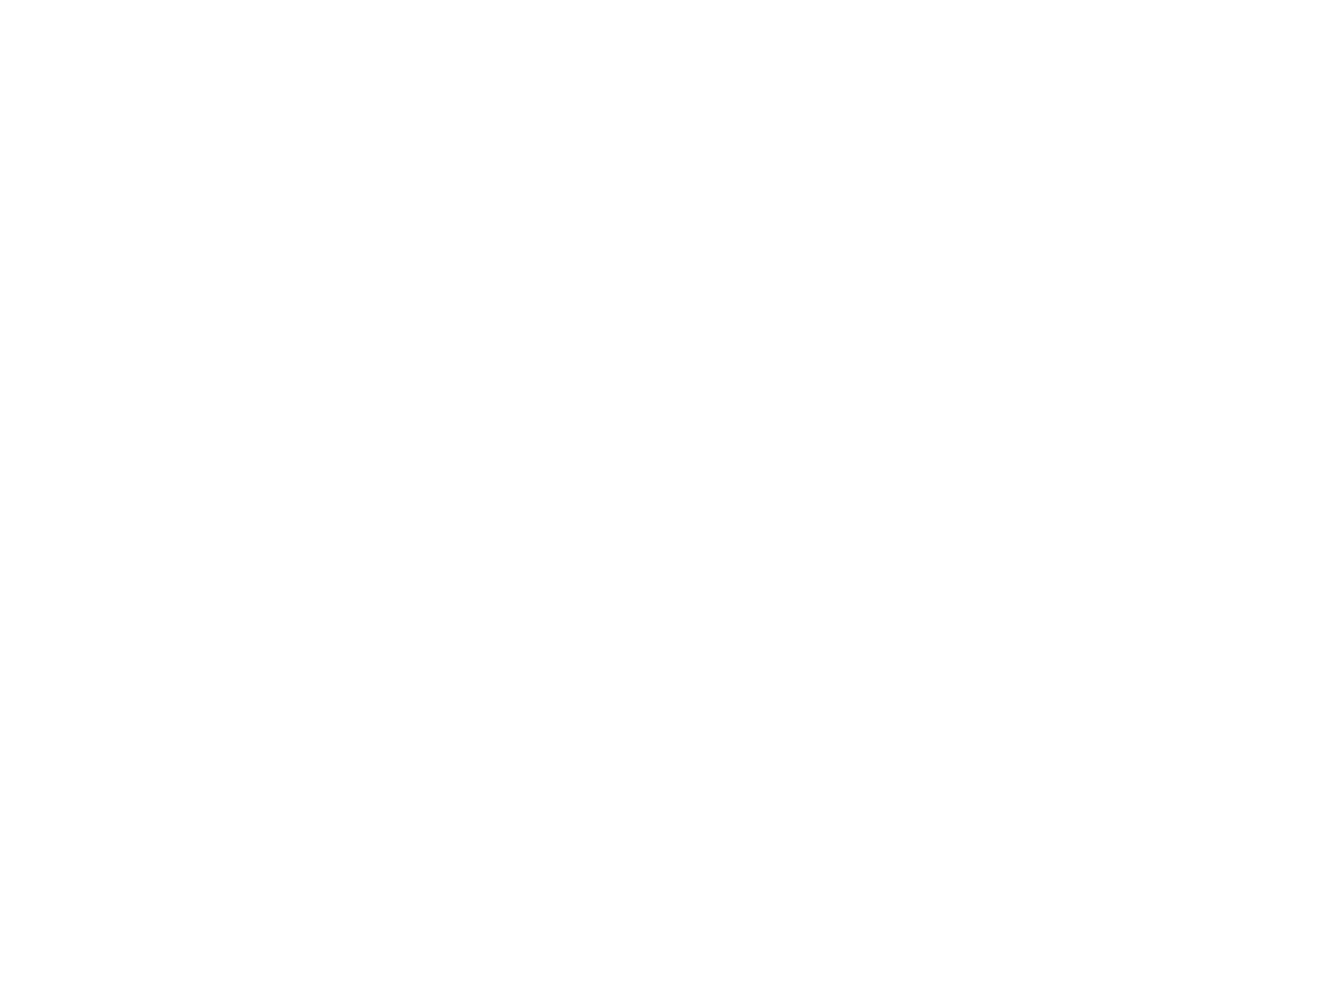


Displaying 3_interpretation_testing.png:


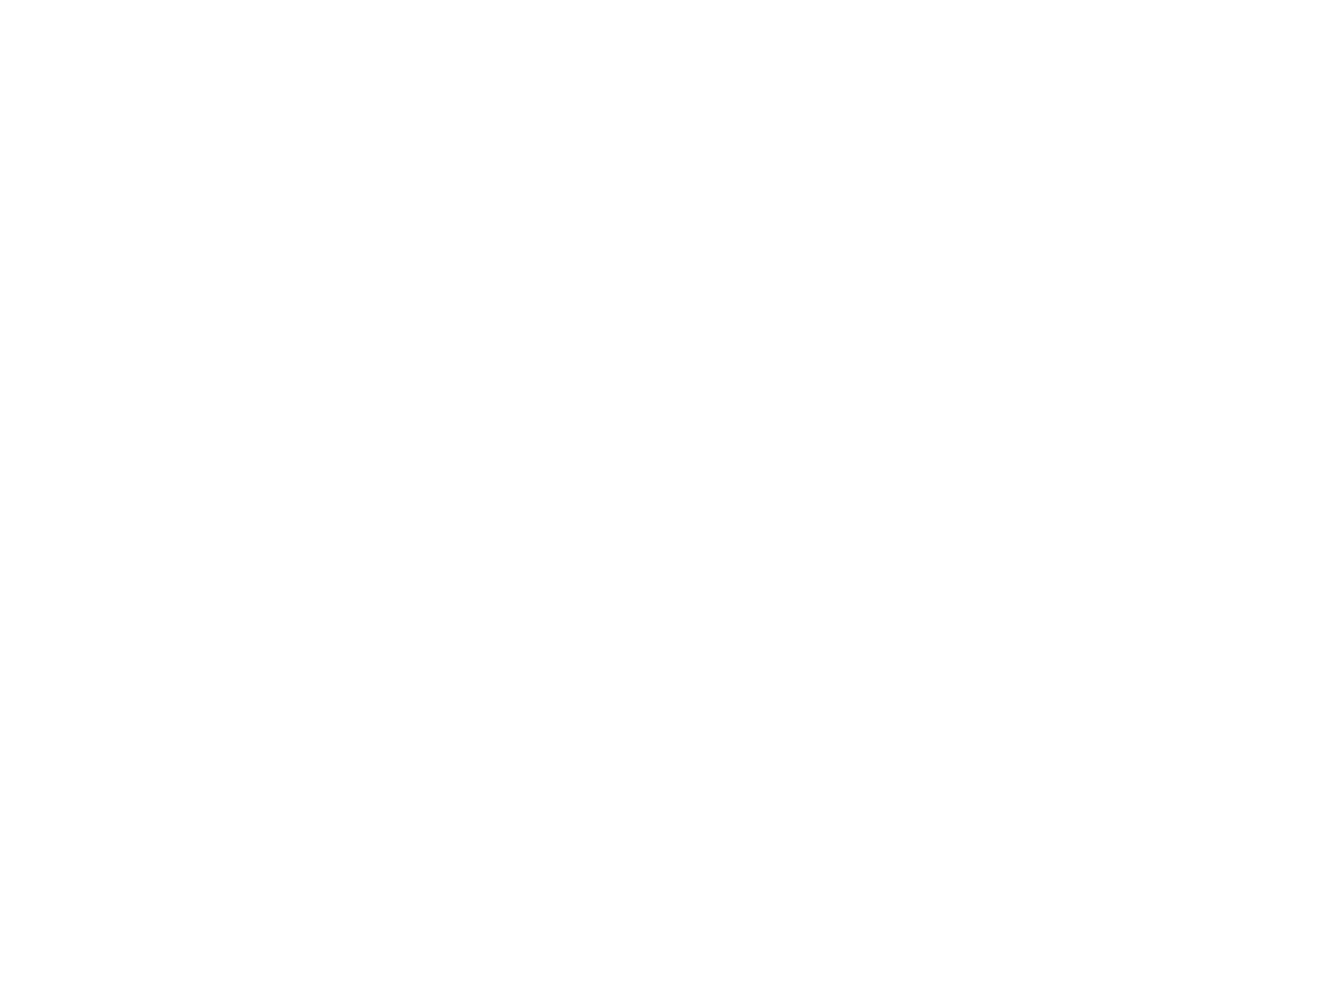


Displaying learning_curves.png:


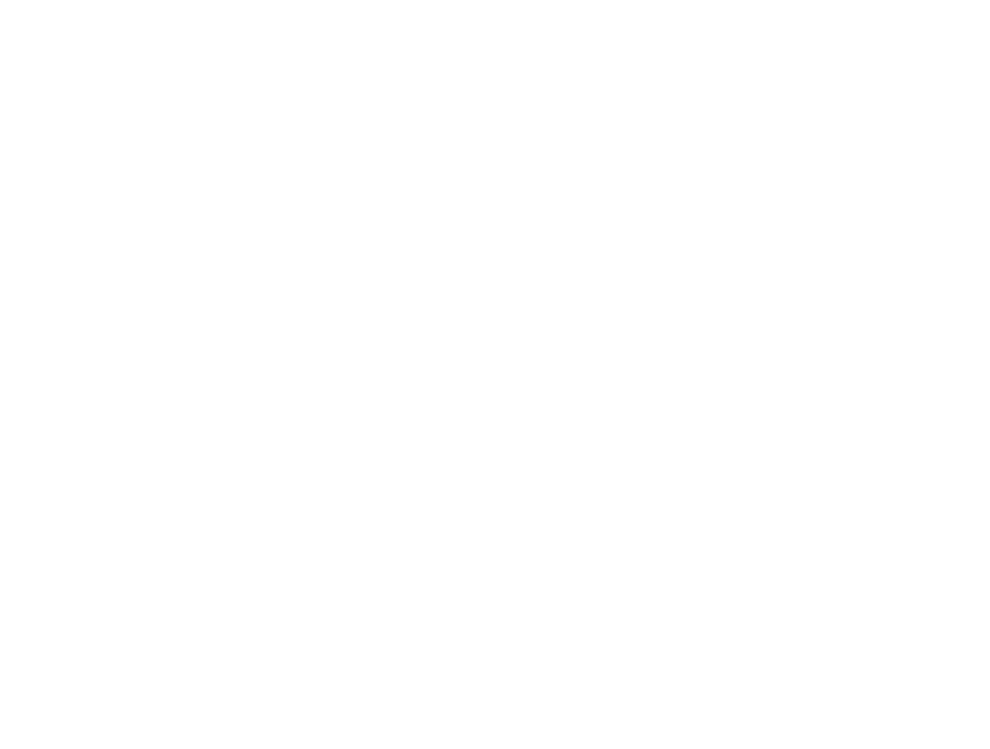


Displaying shap_summary_E2_Sharpe.png:


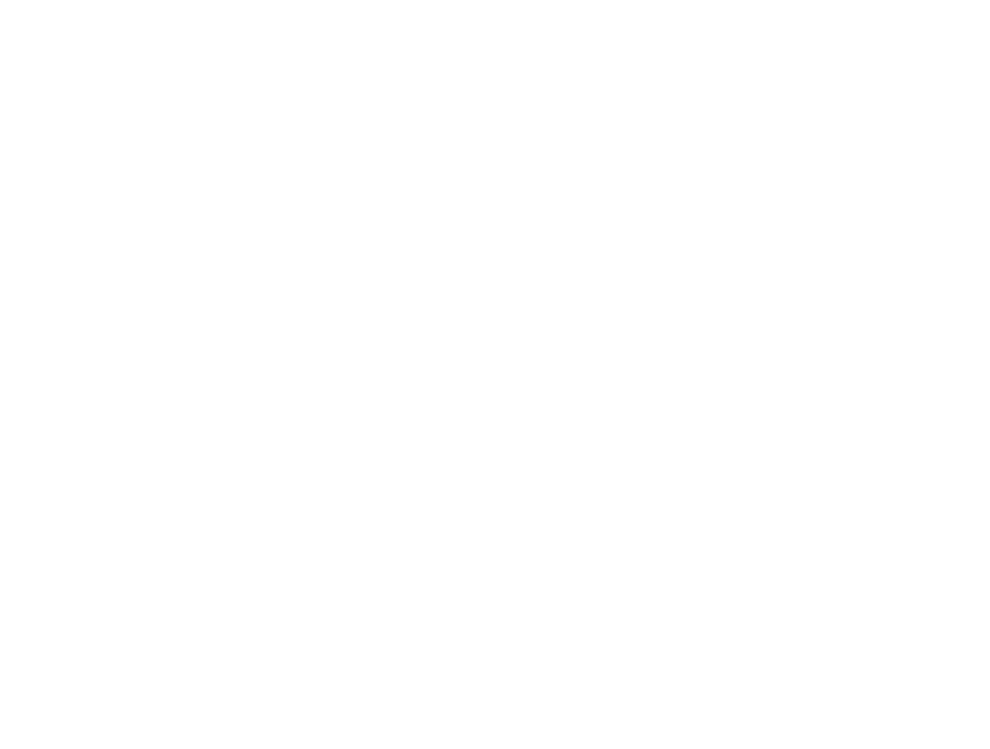


Displaying shap_bar_E2_Sharpe.png:


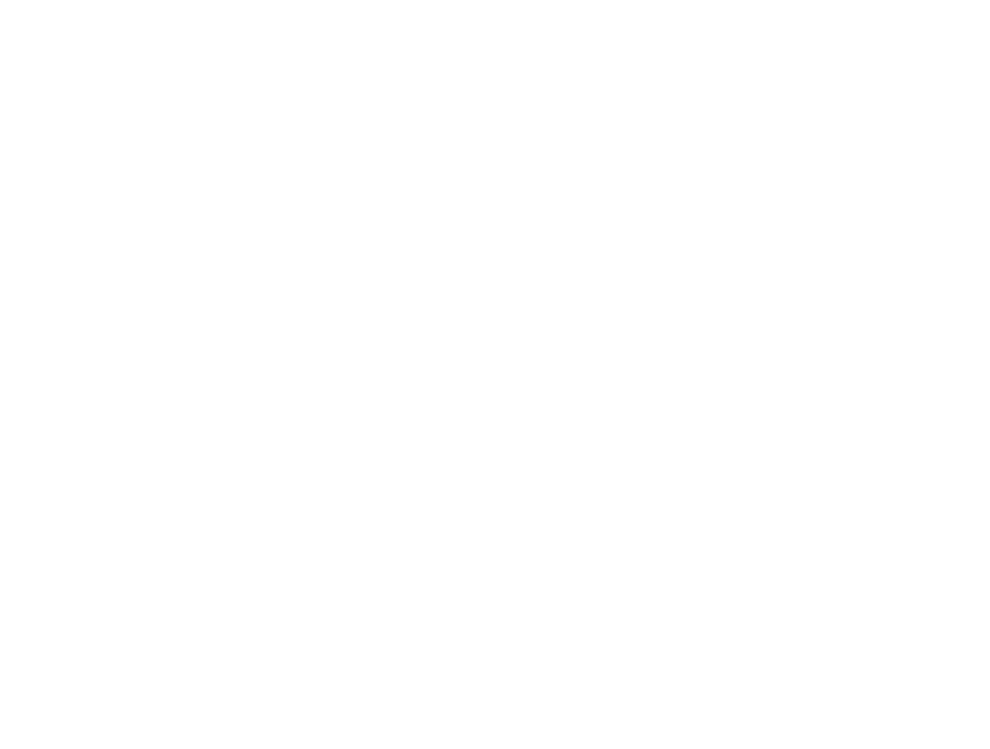


Displaying shap_summary_E2_Sortino.png:


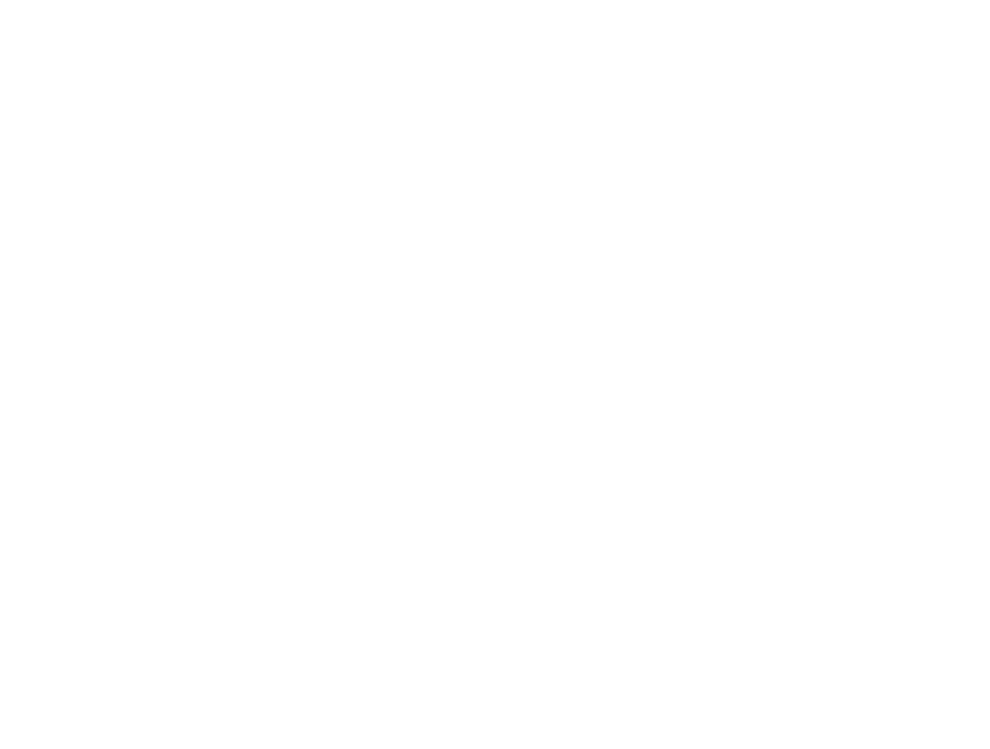


Displaying shap_bar_E2_Sortino.png:


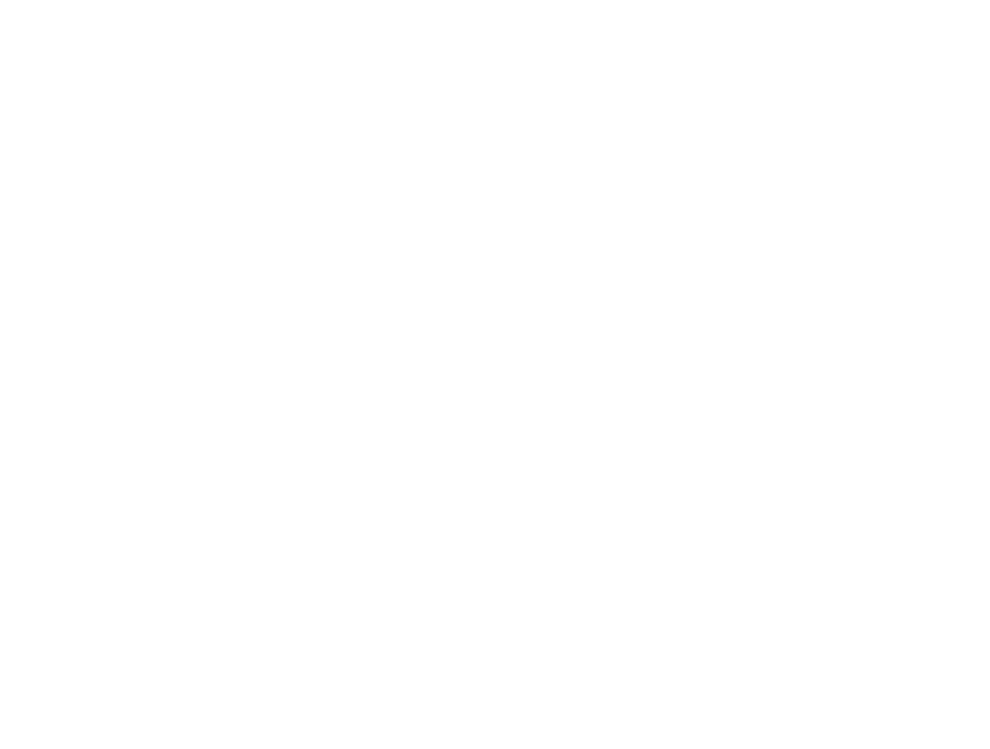


Displaying shap_summary_E2_Calmar.png:


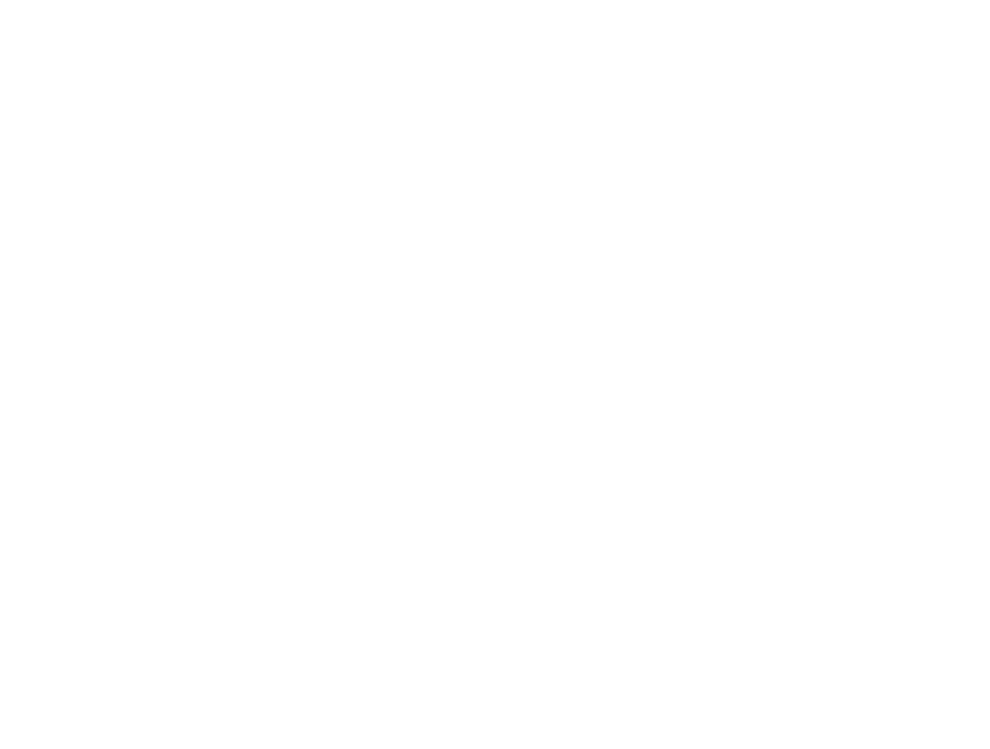


Displaying shap_bar_E2_Calmar.png:


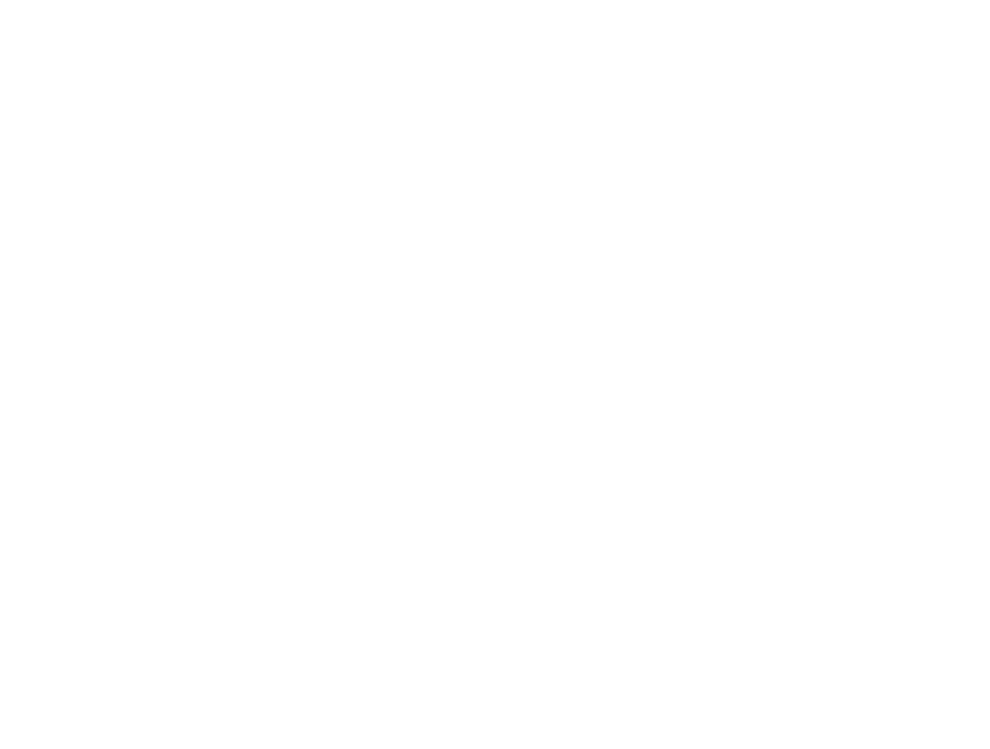


Displaying shap_summary_E2_Ulcer.png:


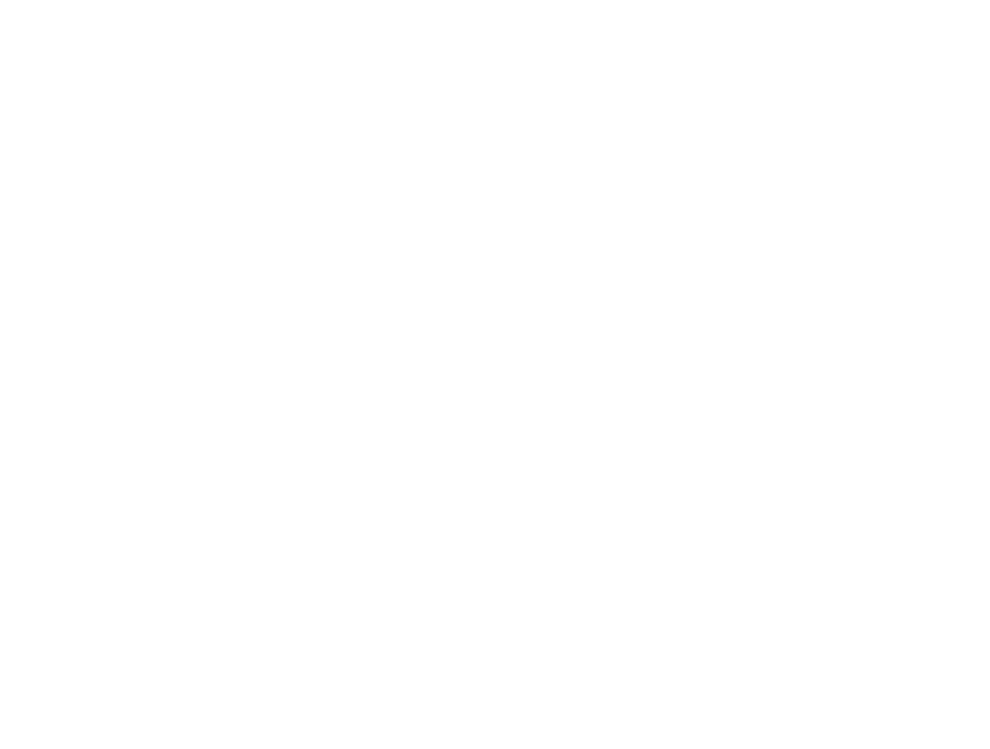


Displaying shap_bar_E2_Ulcer.png:


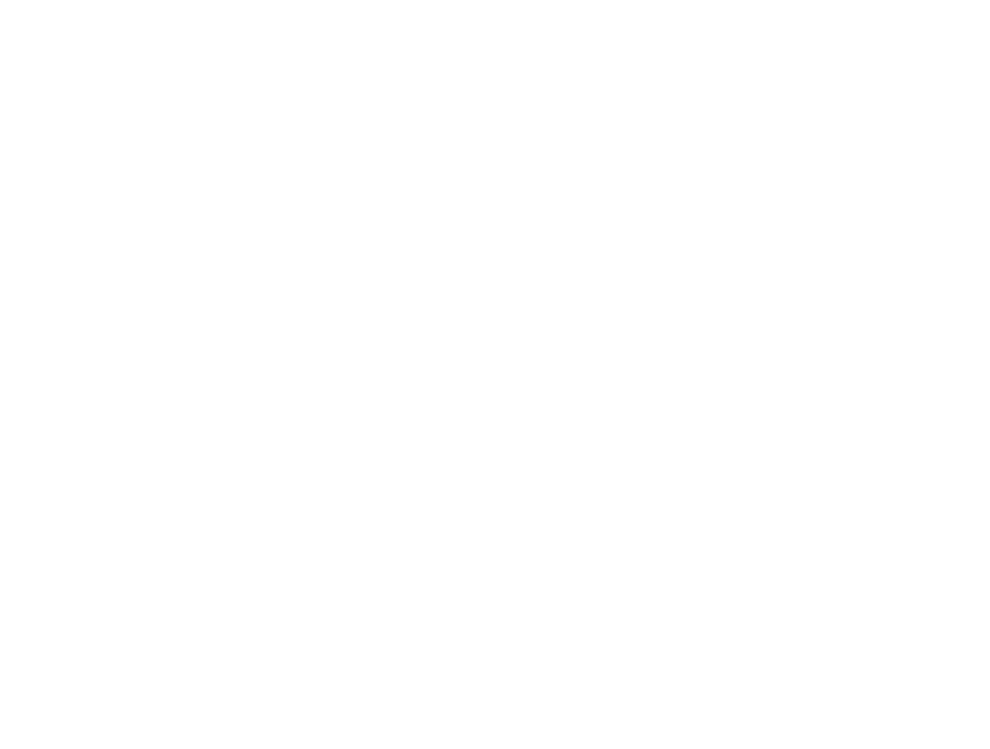


Displaying shap_summary_E2_Ensemble_Avg.png:


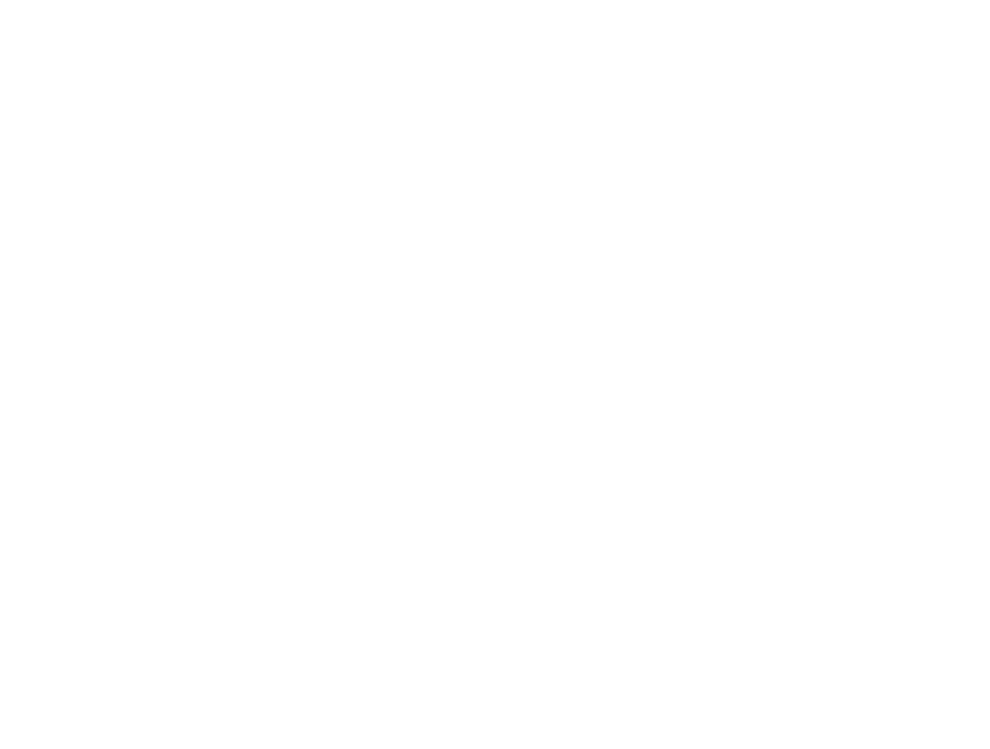


Displaying shap_bar_E2_Ensemble_Avg.png:


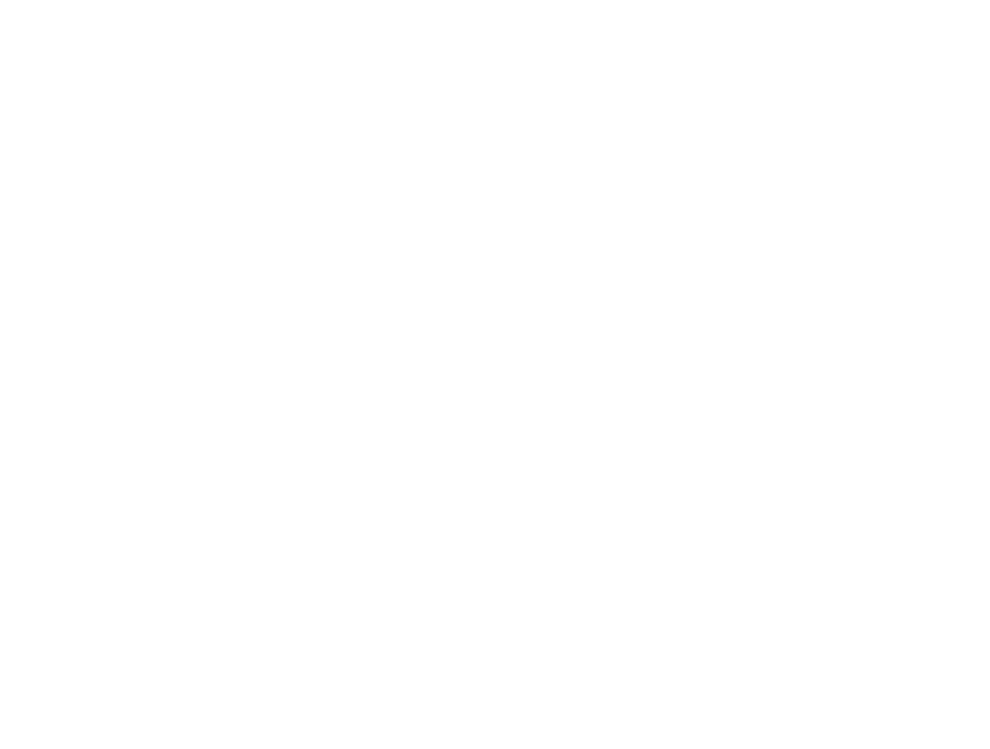

In [16]:
# ================================================================
# RESULTS DISPLAY — PREVIEW SAVED FIGURES
# ================================================================
from IPython.display import Image, display
import os

# Fallback definition jika cell sebelumnya belum dijalankan
if 'OUTPUT_DIR' not in locals():
    OUTPUT_DIR = os.path.join(os.getcwd(), 'ablation_results_thesis')

print("\n--- RESULTS PREVIEW ---")
results_files = [
    '1_metrics_testing.png',
    '2_returns_testing.png',
    '3_interpretation_testing.png',
    'learning_curves.png'
]

if not os.path.exists(OUTPUT_DIR):
    print(f"Directory {OUTPUT_DIR} tidak ditemukan. Pastikan Anda sudah menjalankan proses evaluasi.")
else:
    for f in results_files:
        path = os.path.join(OUTPUT_DIR, f)
        if os.path.exists(path):
            print(f"\nDisplaying {f}:")
            display(Image(filename=path))
        else:
            print(f"\nFile {f} not found in {OUTPUT_DIR}")

    # Display SHAP results if any
    shap_files = [f for f in os.listdir(OUTPUT_DIR) if f.startswith('shap_')]
    for f in shap_files:
        print(f"\nDisplaying {f}:")
        display(Image(filename=os.path.join(OUTPUT_DIR, f)))